In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from h5 import HDFArchive
from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

Starting serial run at: 2026-07-16 11:27:26.260722


SCBA: nk=50^2, niw=128, T=0.1000, mu=0.0000, v=0.050  [numpy.fft]
Converged at step    4  diff=3.636e-11  mu=-0.314818


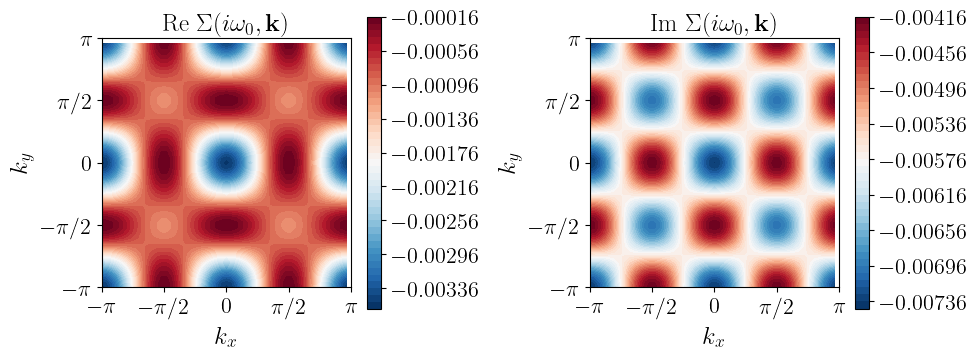

In [ ]:
from scripts.scba import *

lat = LATTICE(dim=2)
nk = 50
bz = BZ(lat, nk=nk)

kx = np.linspace(-np.pi, np.pi, nk, endpoint=False)
ky = np.linspace(-np.pi, np.pi, nk, endpoint=False)
kx, ky = np.meshgrid(kx, ky, indexing='ij')

niw = 128
beta = 1/0.1
n = 0.85
scba = SCBA(lat, bz, niw)
scba.run(0.05, beta, n, ibz=True)

S_iwk = bz.unfold_f_iwk(scba.S_iwk)

S_grid = S_iwk.reshape(niw,nk,nk)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

c0 = axes[0].contourf(kx, ky, S_grid[0].real, levels=50, cmap='RdBu_r')
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r'Re $\Sigma(i\omega_0, \mathbf{k})$')

c1 = axes[1].contourf(kx, ky, S_grid[0].imag, levels=50, cmap='RdBu_r')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r'Im $\Sigma(i\omega_0, \mathbf{k})$')

for ax in axes:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1366: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1367: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/numpy/ma/core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


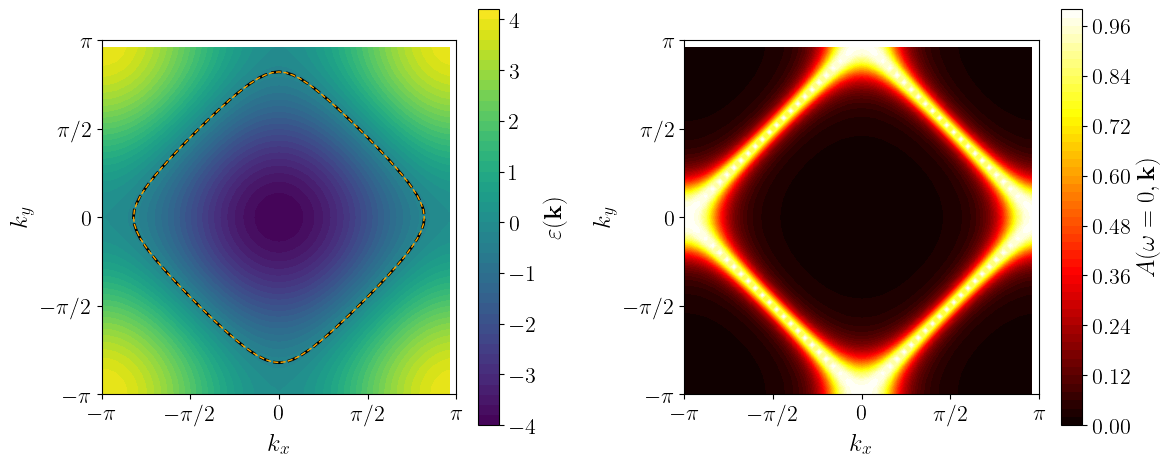

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

lat = LATTICE(dim=2)
bz = BZ(lat, nk=nk, ibz=False)

e_k = bz.e_k.reshape(nk,nk)
Sk0_real = S_iwk[0].reshape(nk,nk)

kx = bz.k_vecs[:,0].reshape(nk,nk)
ky = bz.k_vecs[:,1].reshape(nk,nk)
kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)
Sk0_real = np.roll(np.roll(Sk0_real, nk//2, axis=0), nk//2, axis=1)

G_k_n0 = 1.0 / (1j * np.pi / beta - e_k - Sk0_real)
A_k0 = -G_k_n0.imag / np.pi

cf = axs[0].contourf(kx, ky, e_k - Sk0_real, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')

mu = get_mu(e_k=bz.e_k, n_goal=0.85, beta=1/0.1)
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)
axs[0].contour(kx, ky, e_k - Sk0_real, levels=[mu], colors='orange', linewidths=1)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

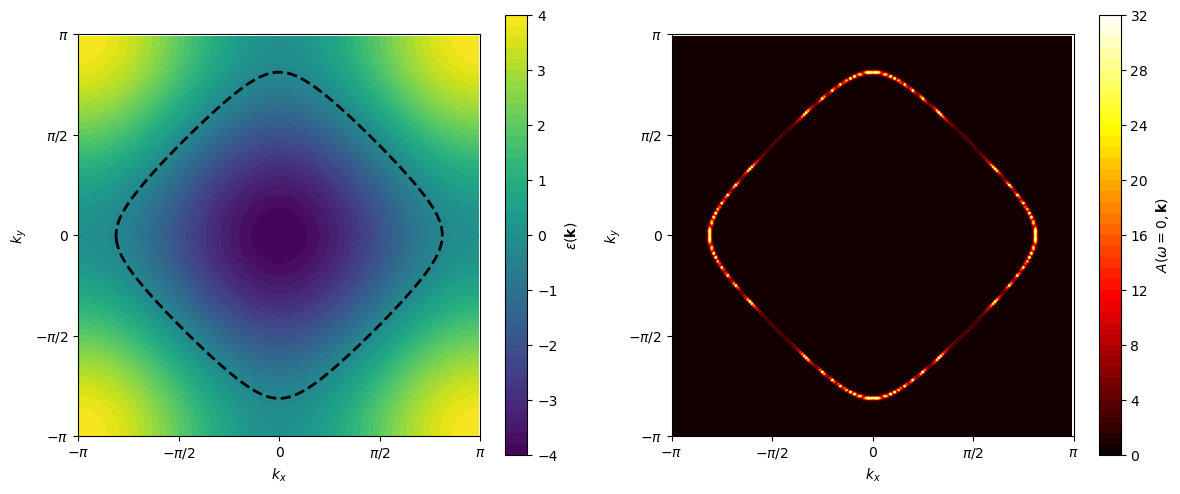

In [ ]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

mu = get_mu(e_k=lat.e_k, n_goal=0.9, beta=1/1)
eta = 0.01
A_k0 = (1/np.pi) * eta / (eta**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

tp : -0.2, mu : [-0.8517850759228668, -0.6716672852022249, -0.46057022123212055], n = [np.float64(0.8), np.float64(0.8999999999998523), np.float64(1.0000000000000262)]
tp : 0.0, mu : [-0.43826440547706147, -0.19845687535815118, 3.907985046680551e-14], n = [np.float64(0.7999999999999953), np.float64(0.8999999999999952), np.float64(1.0000000000000207)]
tp : 0.2, mu : [-0.11835108272199893, 0.19757301236606614, 0.4605702212320972], n = [np.float64(0.8000000000001253), np.float64(0.9000000000000007), np.float64(0.9999999999999641)]


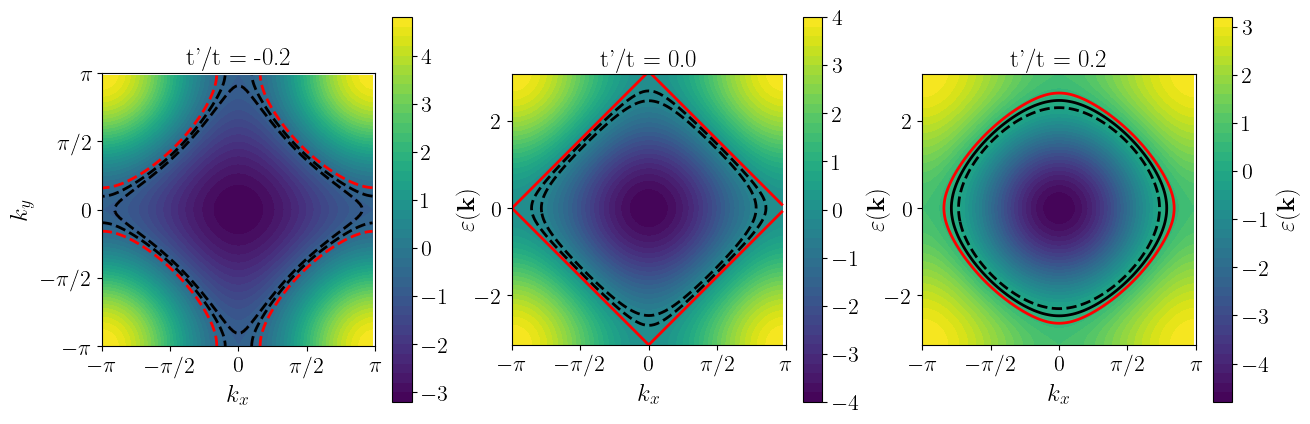

In [116]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

tp_list = [-0.2, 0., 0.2]
for i, tp in enumerate([-0.2, 0., 0.2]):

    lat = LATTICE(dim=2, tp=tp)
    nk = 100

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.1
    n_list = [0.8, 0.9, 1.]
    mu_list = [get_mu(e_k=lat.e_k, n_goal=n, beta=1/T) for n in n_list]
    n_check = [2*np.mean(1/(np.exp((lat.e_k-mu)/T)+1)) for mu in mu_list]

    cf = axs[i].contourf(kx, ky, e_k, levels=50)
    plt.colorbar(cf, ax=axs[i], label=r'$\varepsilon(\mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    axs[i].contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)
    print(f'tp : {tp}, mu : {mu_list}, n = {n_check}')

    axs[i].set_title(f"t'/t = {tp}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

In [34]:
import numpy as np

lat = LATTICE()
bz = BZ(lat, 20)
bz_fine = BZ(lat, 40)
mu = 0.1
beta = 1/0.1
q_min = np.array([1,1,1])
q_path = ([1,1,0.5], [1,1,1])

# Run search_min twice in a row with identical inputs
result1 = search_min(lat, bz, bz_fine, mu, beta, q_min, q_path)
result2 = search_min(lat, bz, bz_fine, mu, beta, q_min, q_path)

print("Run 1:", result1)
print("Run 2:", result2)
print("Difference:", np.array(result1[0]) - np.array(result2[0]))

Run 1: (array([1., 1., 1.]), 2.0495704557675083)
Run 2: (array([1.        , 1.        , 0.99999959]), 2.0495704495916076)
Difference: [0.00000000e+00 0.00000000e+00 4.10559491e-07]


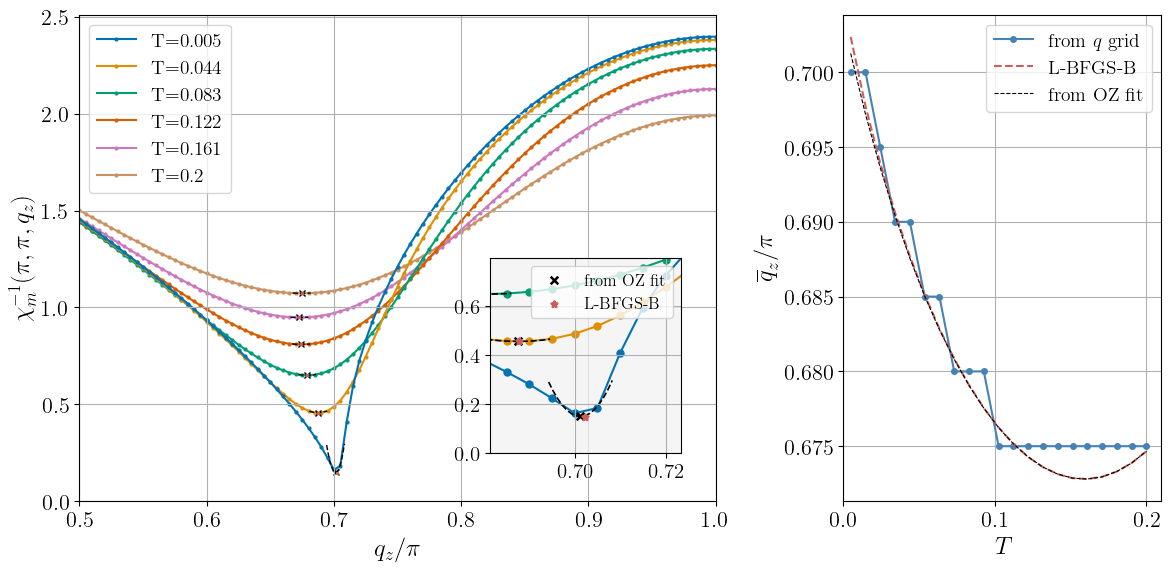

In [83]:
n = 0.745
U = 3

with HDFArchive(f"data/chimin/tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

<unknown>:37: SyntaxWarning: invalid escape sequence '\p'
<unknown>:37: SyntaxWarning: invalid escape sequence '\p'


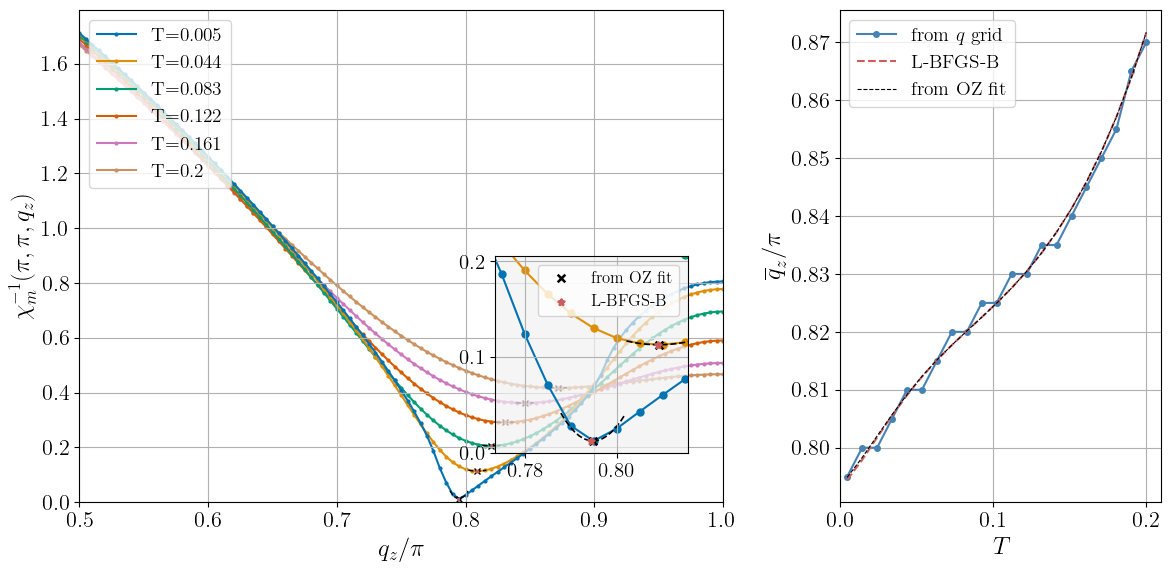

In [81]:
n = 0.8485
U = 3
tp = 0.1

with HDFArchive(f"data/chimin/tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

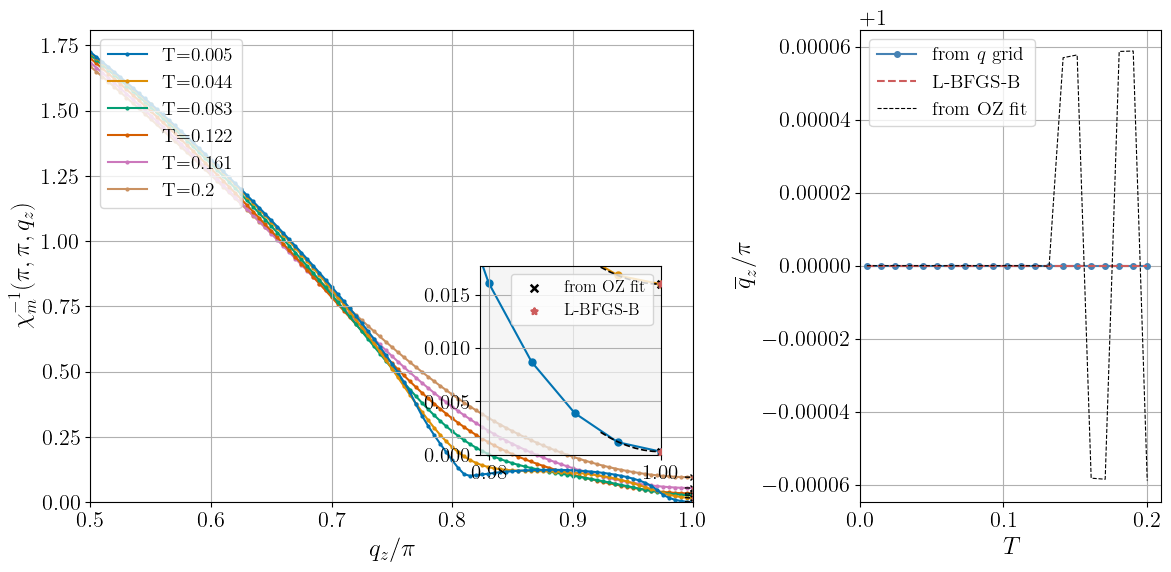

In [82]:
n = 0.88493
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/chimin/tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

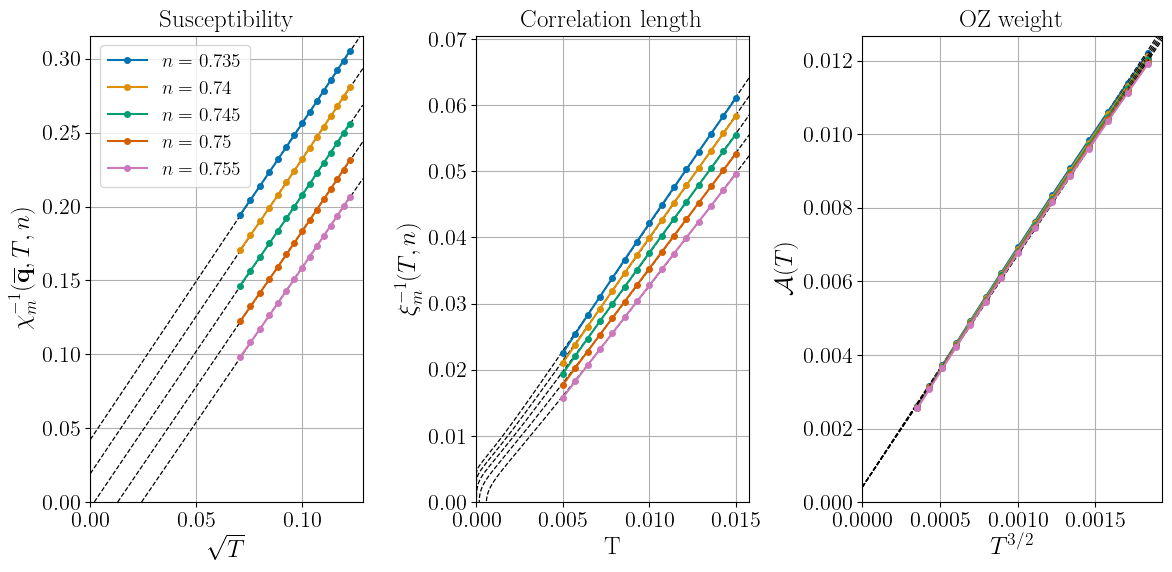

In [24]:
U = 3
tp = 0.

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1., 3/2), fit=True, right='OZ')
plt.show()

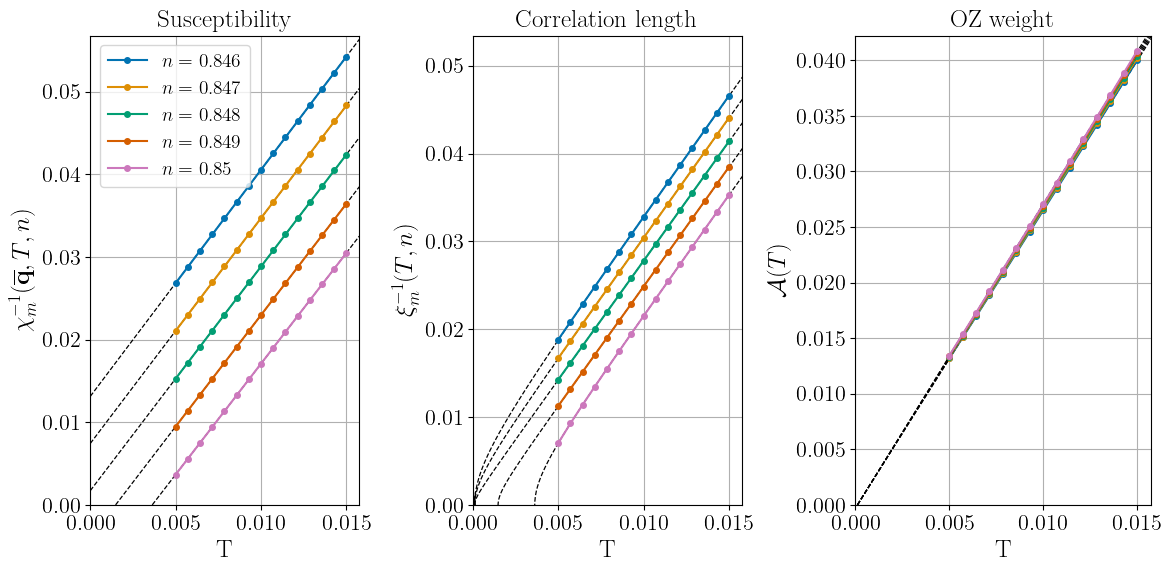

In [12]:
U = 3
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1., 1., 1.), fit=True, right='OZ')
plt.show()

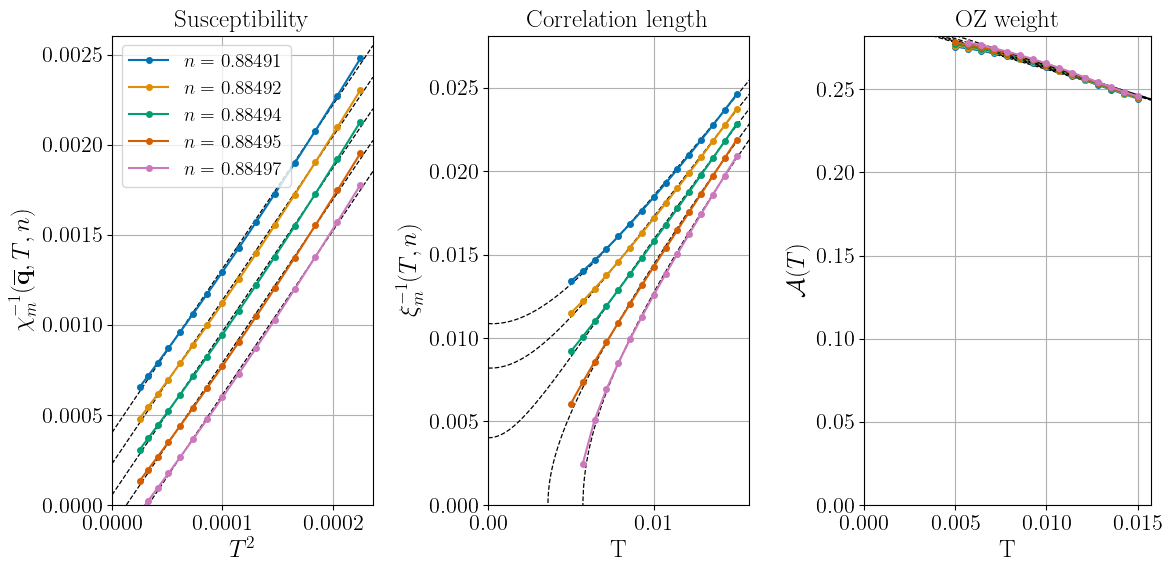

In [13]:
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.), fit=True, right='OZ')
plt.show()

/home/carlo/Desktop/qc/scripts/plot.py:467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


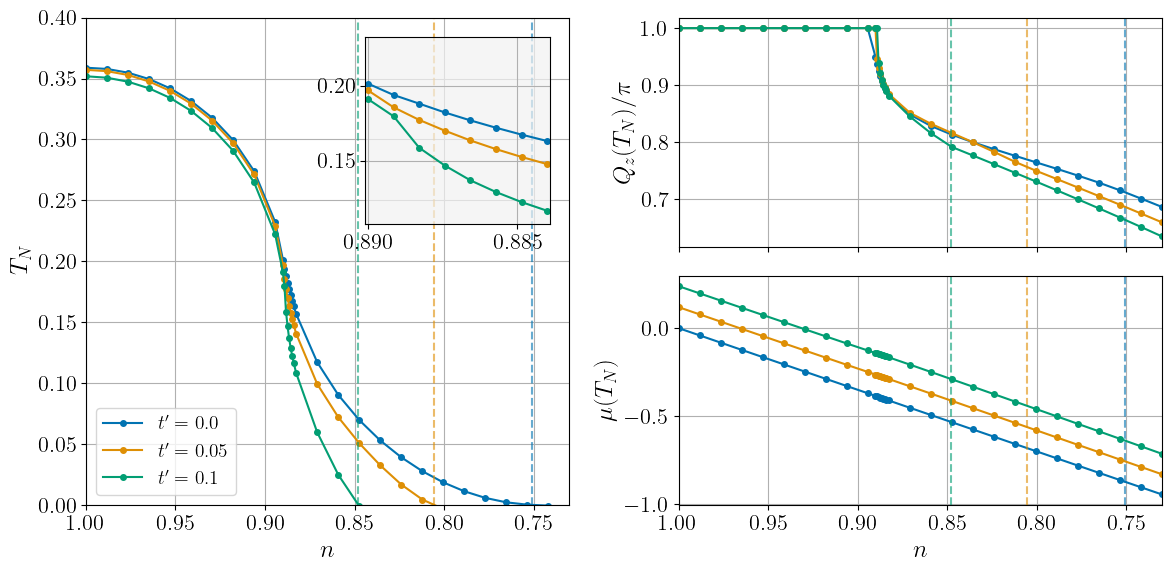

/home/carlo/Desktop/qc/scripts/plot.py:424: RuntimeWarning: overflow encountered in power
  y2 = -abs(data['cOZ']/data['aOZ'])**(1/data['bOZ']) * np.sign(data['cOZ']/data['aOZ'])
/home/carlo/Desktop/qc/scripts/plot.py:467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


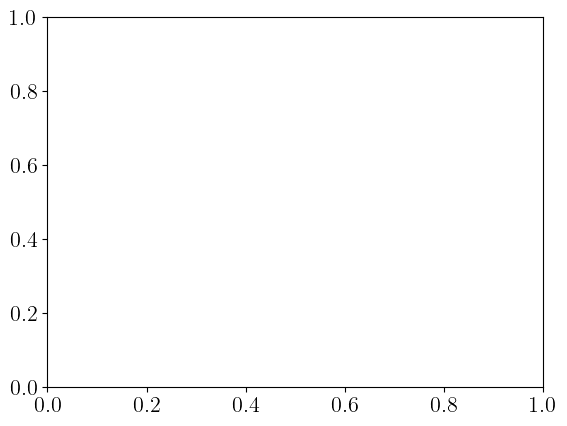

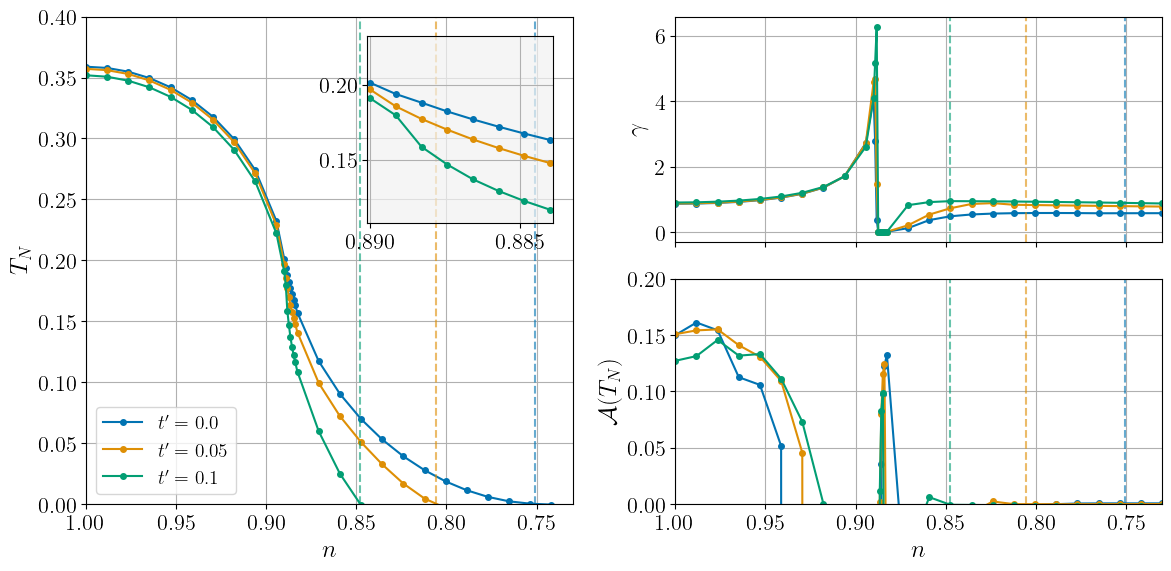

In [2]:
U = 3
tp_list = [0., 0.05, 0.1]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='commens')
plt.show()

plt.cla()
plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='scaling')
plt.show()

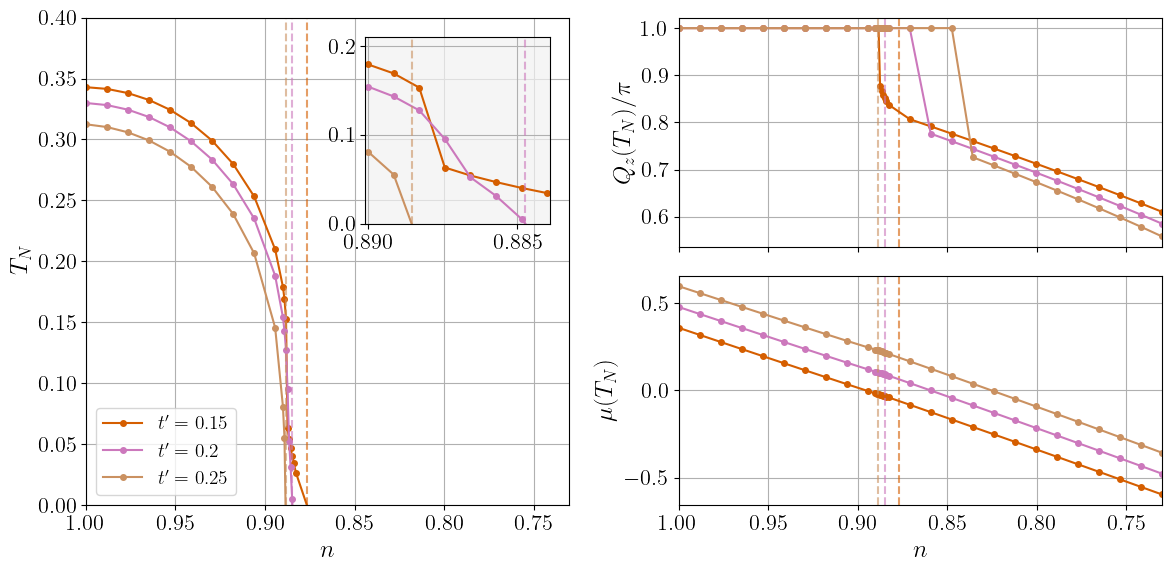

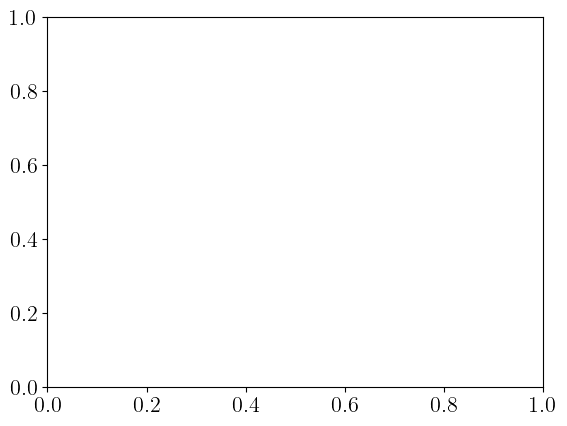

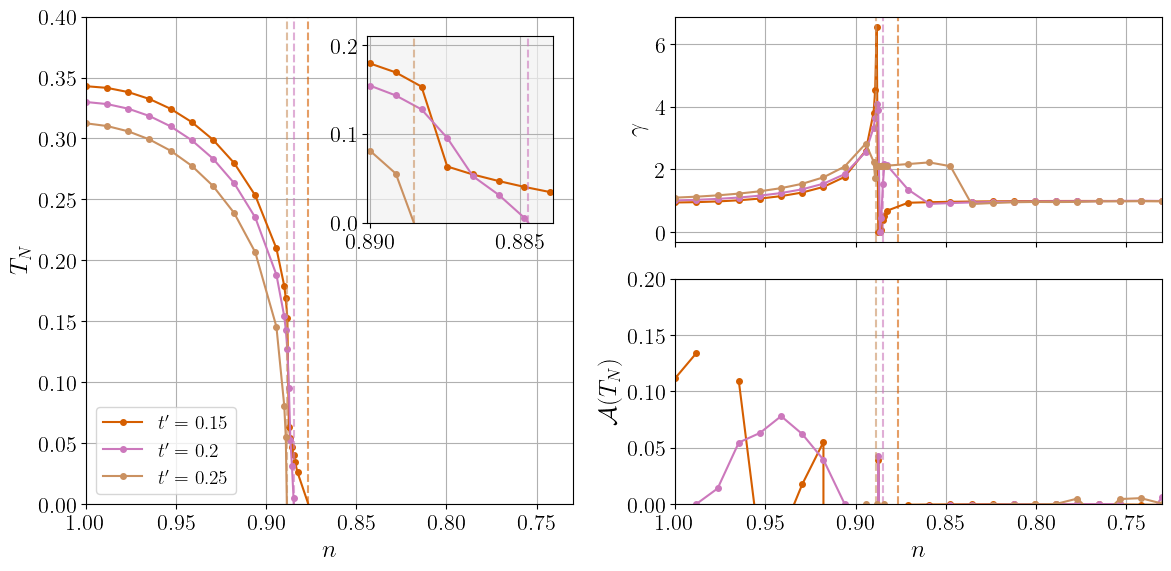

In [3]:
U = 3
tp_list = [0.15, 0.2, 0.25]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='commens', c0=3)
plt.show()

plt.cla()
plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='scaling', c0=3)
plt.show()